## Theoretical pacing functions

In [14]:
from matplotlib import pyplot as plt
import numpy as np

MSS = 1500 
PACING_RATE = 200
RTT_US = 50_000

def linux_pacing_function(mss, pacing_rate, cwnd, rtt):
    return ((mss * 80000 * pacing_rate * cwnd) / (rtt * 8)) / 1000  


def custom_pacing_function(mss, packet_number, rtt):
    return ((mss * 1000000 * 8) / ((np.log2(packet_number + 1) - np.log2(packet_number)) * rtt * 8)) / 1000



Custom 15: 322.20160998844


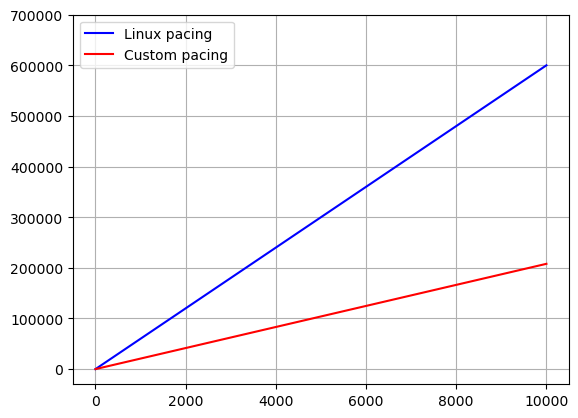

In [20]:
x = np.linspace(1, 10000, 200)
y = linux_pacing_function(MSS, PACING_RATE, x, RTT_US)

print(f"Custom 15: {custom_pacing_function(MSS, 15, RTT_US)}")

y2 = custom_pacing_function(MSS, x, RTT_US)

plt.plot(x, y, color='blue', label='Linux pacing')
plt.plot(x, y2, color='red', label='Custom pacing')
plt.grid()
plt.legend()

plt.yticks(np.arange(0, 750000, 100000))
plt.show()